**Titanic Keggle Data Set Exploration**

In [2]:
# install the required dependencies
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#load the dataset
df = pd.read_csv("titanic.csv")


In [18]:
df.shape

(891, 12)

In [19]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Check & Handle Missing Values**

In [24]:
# Check missing values
print("\nMissing values in each column:")
print(df.isnull().sum())



Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [25]:
#handle missing values
# Fill missing 'Age' values with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)
# Fill missing 'Embarked' values with the mode (most frequent value)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Verify that there are no more missing values
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [26]:
print(df["Embarked"])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object


**Survival Analysis**

**Average age & fair**

In [27]:
print("Avg Age:", df["Age"].mean())
print("Avg fare:", df["Fare"].mean())

Avg Age: 29.36158249158249
Avg fare: 32.204207968574636


**Visualization**


/var/folders/zp/zh_rycfs4j14qq7_xth9cy8h0000gn/T/ipykernel_4201/4116870046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Survived", palette="Set2")


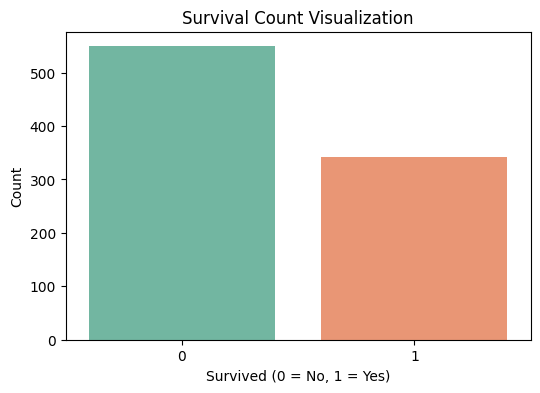

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived", palette="Set2")
plt.title("Survival Count Visualization")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

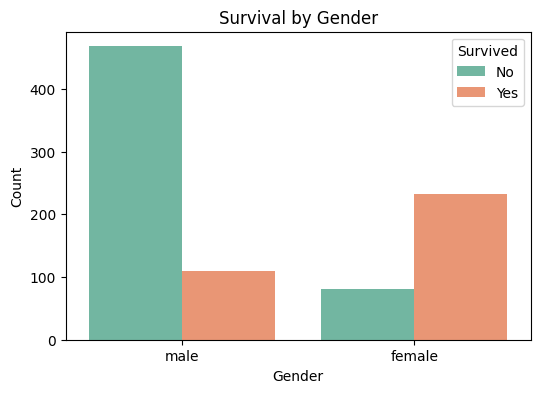

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

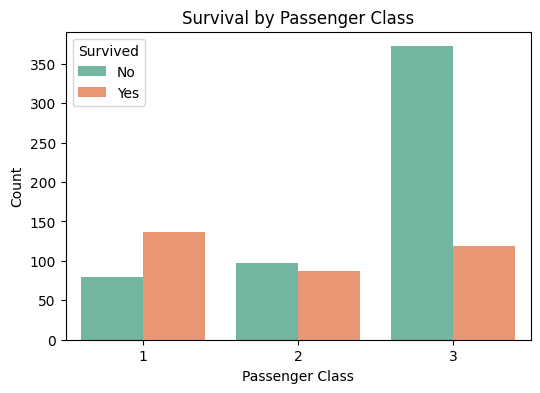

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

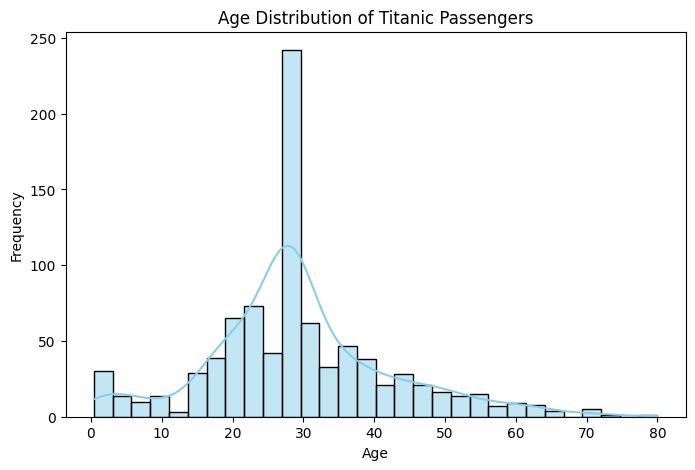

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=30, kde=True, color="skyblue")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

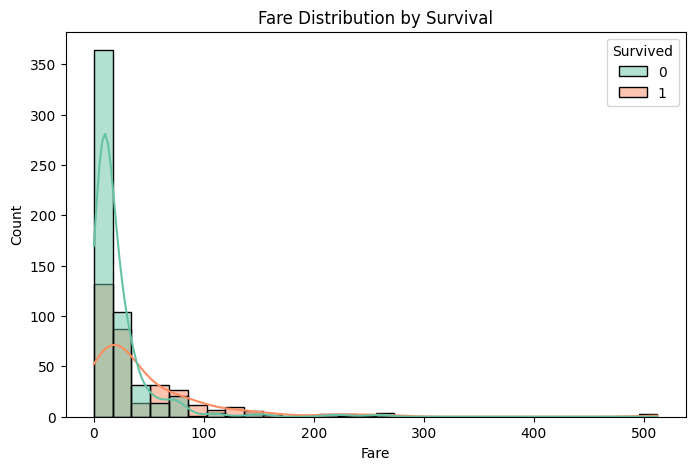

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Fare", hue="Survived", bins=30, kde=True, palette="Set2")
plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

**age group analysis**

/var/folders/zp/zh_rycfs4j14qq7_xth9cy8h0000gn/T/ipykernel_4201/1116443117.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate_by_age, x="AgeGroup", y="Survived", palette="Set2")


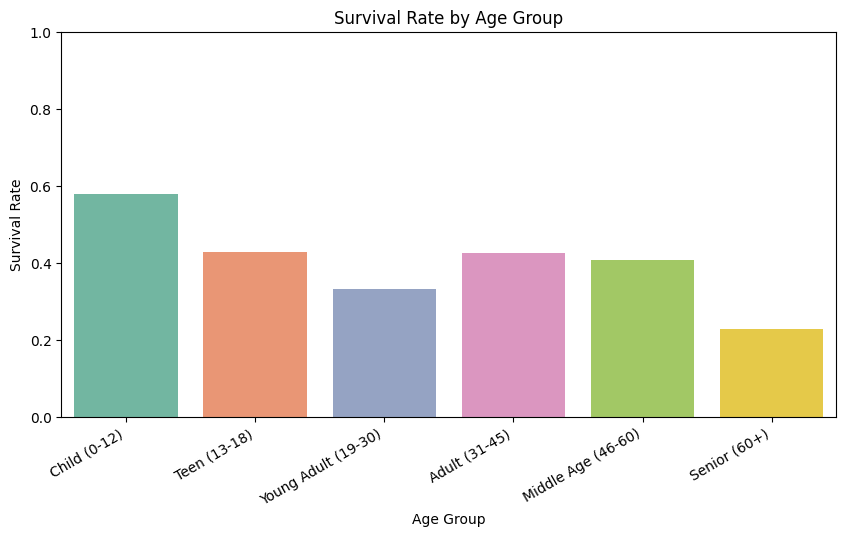

,AgeGroup,Survived
0,Child (0-12),0.579710
1,Teen (13-18),0.428571
2,Young Adult (19-30),0.331096
3,Adult (31-45),0.425743
4,Middle Age (46-60),0.407407
5,Senior (60+),0.227273


In [36]:
# Survival rate by age group analysis
age_bins = [0, 12, 18, 30, 45, 60, np.inf]
age_labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-30)", "Adult (31-45)", "Middle Age (46-60)", "Senior (60+)"]

df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=True)

survival_rate_by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=survival_rate_by_age, x="AgeGroup", y="Survived", palette="Set2")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()

survival_rate_by_age